# Практична робота №18
## Множинна лінійна регресія: відбір предикторів, інтерпретація коефіцієнтів, діагностика залишків
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів)  
**№ у журналі:** 26


In [1]:
import numpy as np
import pandas as pd

np.random.seed(6)
city = "Чернігів"
mean_temp = 8.0
amplitude = 13.0
hum_base = 75.0

data_rows = []
for month in range(1, 13):
    temp = mean_temp + amplitude * np.cos((month - 7) / 12 * 2 * np.pi) + np.random.normal(0, 1.0)
    humidity = hum_base + np.random.normal(0, 5.0)
    if temp < 8:
        heating_days = 30
    elif temp < 12:
        heating_days = 15
    else:
        heating_days = 0
    cost = 200 - 9.0 * temp + 0.6 * humidity + 2.5 * heating_days + np.random.normal(0, 15)
    data_rows.append({
        "місто": city,
        "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": round(cost, 1)
    })

heating = pd.DataFrame(data_rows)
print(heating.head())


      місто  місяць  ...  опалювальні_дні  витрати_на_опалення
0  Чернігів       1  ...               30                373.3
1  Чернігів       2  ...               30                363.7
2  Чернігів       3  ...               30                316.4
3  Чернігів       4  ...               30                268.8
4  Чернігів       5  ...                0                122.9

[5 rows x 6 columns]


In [2]:
import statsmodels.api as sm

X2 = heating[["температура", "вологість"]]
X2 = sm.add_constant(X2)
y = heating["витрати_на_опалення"]

model_2vars = sm.OLS(y, X2).fit()
print(model_2vars.summary())


                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.980
Model:                             OLS   Adj. R-squared:                  0.976
Method:                  Least Squares   F-statistic:                     222.5
Date:                 Tue, 06 Oct 2026   Prob (F-statistic):           2.18e-08
Time:                         23:18:48   Log-Likelihood:                -51.154
No. Observations:                   12   AIC:                             108.3
Df Residuals:                        9   BIC:                             109.8
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         273.4502     61.726      4

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Предиктор"] = X2.columns
vif_df["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print("Оцінка мультиколінеарності (VIF):")
print(vif_df)


Оцінка мультиколінеарності (VIF):
     Предиктор       VIF
0        const  1.000000
1  температура  1.039927
2    вологість  1.039927


In [4]:
X3 = heating[["температура", "вологість", "опалювальні_дні"]]
X3 = sm.add_constant(X3)
model_3vars = sm.OLS(y, X3).fit()

print(f"Модель із 2 предикторами: R² = {model_2vars.rsquared:.3f}, Adj R² = {model_2vars.rsquared_adj:.3f}")
print(f"Модель із 3 предикторами: R² = {model_3vars.rsquared:.3f}, Adj R² = {model_3vars.rsquared_adj:.3f}")


Модель із 2 предикторами: R² = 0.980, Adj R² = 0.976
Модель із 3 предикторами: R² = 0.996, Adj R² = 0.994


Критерій Шапіро-Вілка: W = 0.936, p-value = 0.451
Висновок: Гіпотеза про нормальний розподіл залишків підтверджується (H0 не відхиляється).


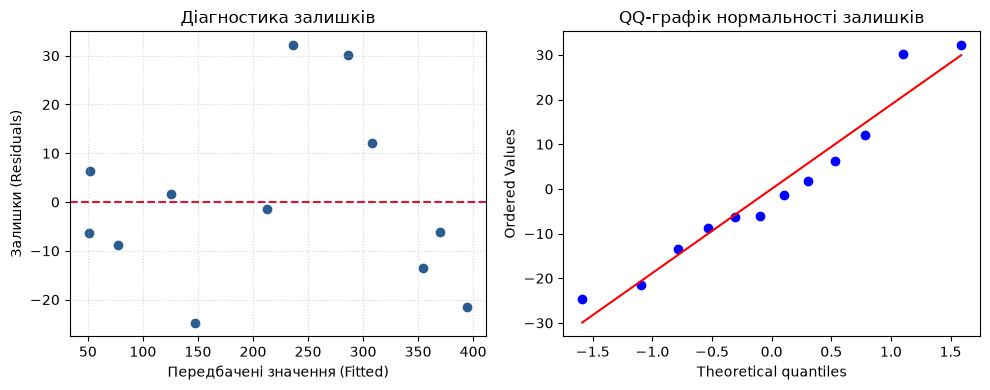

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import probplot, shapiro

res = model_2vars.resid
fits = model_2vars.fittedvalues

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(fits, res, color="#2b5c8f")
plt.axhline(0, color="crimson", linestyle="--")
plt.xlabel("Передбачені значення (Fitted)")
plt.ylabel("Залишки (Residuals)")
plt.title("Діагностика залишків")
plt.grid(True, linestyle=":", alpha=0.5)

plt.subplot(1, 2, 2)
probplot(res, dist="norm", plot=plt)
plt.title("QQ-графік нормальності залишків")

plt.tight_layout()
plt.show()

sw_stat, sw_pval = shapiro(res)
print(f"Критерій Шапіро-Вілка: W = {sw_stat:.3f}, p-value = {sw_pval:.3f}")
if sw_pval > 0.05:
    print("Висновок: Гіпотеза про нормальний розподіл залишків підтверджується (H0 не відхиляється).")
else:
    print("Висновок: Залишки суттєво відхиляються від нормального розподілу.")


In [6]:
X1 = heating[["температура"]]
X1 = sm.add_constant(X1)
model_simple = sm.OLS(y, X1).fit()

print(f"Парна регресія: R² = {model_simple.rsquared:.3f}, Adj R² = {model_simple.rsquared_adj:.3f}")
print(f"Множинна регресія: R² = {model_2vars.rsquared:.3f}, Adj R² = {model_2vars.rsquared_adj:.3f}")


Парна регресія: R² = 0.979, Adj R² = 0.977
Множинна регресія: R² = 0.980, Adj R² = 0.976


### Відповіді на контрольні запитання

1. **Чому виклик sm.add_constant() є обов'язковим перед оцінюванням через sm.OLS() і що буде, якщо його не додати?**  
   За замовчуванням `statsmodels.OLS` не включає константу (вільний член $\beta_0$) до матриці плану. Якщо не викликати `sm.add_constant()`, лінія регресії буде примусово проходити через початок координат $(0, 0)$. Це спотворює оцінки коефіцієнтів, призводить до невалідності показника $R^2$ (який може стати навіть від'ємним) та зміщення залишків.

2. **Чим коефіцієнт у множинній регресії відрізняється від коефіцієнта простої парної регресії?**  
   У простій регресії коефіцієнт відображає маргінальний сумарний зв'язок між $X$ та $Y$. У множинній регресії він має зміст *часткового* (partiel) нахилу — показує зміну відгуку $Y$ при зміні конкретного предиктора на 1 за умови фіксації (константності) усіх інших включених у модель предикторів ("ceteris paribus").

3. **Чому звичайний R² монотонно не спадає при додаванні нових змінних і чому він непридатний для порівняння складніших моделей?**  
   Додавання будь-якого додаткового предиктора, навіть чистого шуму, чисто механічно зменшує або залишає незмінною суму квадратів залишків (RSS), через що $R^2$ тільки зростає. Скоригований коефіцієнт $Adjusted\ R^2$ накладає штраф за кожен доданий ступінь вільності (кількість параметрів $p$), що дозволяє уникати перенавчання (overfitting).

4. **Що означають значення VIF близькі до 1 та вищі за 10 і як протидіяти мультиколінеарності?**  
   - $VIF \approx 1$ свідчить про повну ортогональність (відсутність лінійної залежності між предикторами).
   - $VIF > 10$ сигналізує про критичну мультиколінеарність, яка різко роздуває стандартні похибки оцінок та робить коефіцієнти статистично незначущими.
   - Для усунення проблеми видаляють дублюючі змінні, застосовують регуляризацію (Ridge/Lasso) або метод головних компонент (PCA).

5. **Як аналіз залишків дає змогу оцінити адекватність моделі?**  
   Графік залежності залишків від прогнозів виявляє можливу нелінійність та гетероскедастичність (неоднорідність розсіювання). Графік квантилів (QQ-plot) та тест Шапіро-Вілка перевіряють нормальність розподілу помилок, яка є базовою умовою для коректності побудови довірчих інтервалів і t-тестів коефіцієнтів.
